# Caso People Analytics I: Effective Onboarding Process

En este notebook vamos a analizar la calidad del onboarding y su relación
con la salida durante el periodo de prueba.

Primero vamos a:

1. Cargar las librerías necesarias
2. Subir el dataset
3. Comprobar que los datos se han cargado correctamente

Trabajaremos paso a paso para entender todo el proceso.

In [ ]:
# Importamos las librerias necesarias para EDA

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización básica
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Cargamos el CSV y lo vemos con un head

# Pillamos la url del archivo

url = "https://raw.githubusercontent.com/Pablolg87/people-analytics-onboarding/main/onboarding_dataset.csv"

# Leemos el archivo CSV
employees = pd.read_csv(url)

# Mostramos las primeras filas
employees.head(20)

,employee_id,department,location,hire_date,onboarding_survey_date,role_clarity_score,training_quality_score,manager_support_score,tooling_access_score,onboarding_nps,left_during_probation
0,E10070,Engineering,Remote-ES,2024-03-12,30/04/2024,9,4,5.0,9,6.8,0
1,E10218,Customer Success,Valencia,2025/06/01,08-04-2025,3,6,8.0,9,6.5,0
2,E10385,Engineering,Remote-ES,10-25-2024,2024/12/16,3,4,6.0,8,5.2,1
3,E10033,Engineering,Madrid,2025/01/04,2025/02/17,6,8,7.0,6,6.8,0
4,E10042,Data,Barcelona,02-01-2025,03-21-2025,9,9,9.0,8,8.8,0
5,E10077,HR,Seville,2025-11-23,2026/02/11,8,5,9.0,9,7.8,0
6,E10137,HR,Remote-ES,12-14-2025,2026-02-14,4,5,3.0,6,4.5,1
7,E10332,Product,Madrid,2025/05/09,01/07/2025,8,7,5.0,8,7.0,0
8,E10364,Product,Remote-ES,24/03/2025,05-04-2025,3,4,6.0,9,5.5,0
9,E10265,Engineering,Madrid,12-19-2024,2025/01/24,6,7,9.0,5,6.8,0


Hacemos un EDA preliminar, vemos el tamaño e info:

In [ ]:
# Dimensiones del dataset
print("Dimensiones del dataset:", employees.shape)

# Información general
employees.info()

Dimensiones del dataset: (405, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405 entries, 0 to 404
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   employee_id             405 non-null    object 
 1   department              405 non-null    object 
 2   location                405 non-null    object 
 3   hire_date               405 non-null    object 
 4   onboarding_survey_date  405 non-null    object 
 5   role_clarity_score      405 non-null    int64  
 6   training_quality_score  405 non-null    int64  
 7   manager_support_score   395 non-null    float64
 8   tooling_access_score    405 non-null    int64  
 9   onboarding_nps          395 non-null    float64
 10  left_during_probation   405 non-null    int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 34.9+ KB


Revisamos las variables

In [ ]:
employees.describe()

,role_clarity_score,training_quality_score,manager_support_score,tooling_access_score,onboarding_nps,left_during_probation
count,405.000000,405.000000,395.000000,405.000000,395.000000,405.000000
mean,5.970370,6.451852,6.187342,7.024691,6.407089,0.219753
std,2.014578,1.671182,1.913177,1.403455,0.897204,0.414591
min,3.000000,4.000000,3.000000,5.000000,4.200000,0.000000
25%,4.000000,5.000000,5.000000,6.000000,5.800000,0.000000
50%,6.000000,7.000000,6.000000,7.000000,6.500000,0.000000
75%,8.000000,8.000000,8.000000,8.000000,7.000000,0.000000
max,9.000000,9.000000,9.000000,9.000000,8.800000,1.000000


Cambiamos tipo de datos necesarios

In [ ]:
#Fijamos tipo fecha en los campos necesarios

employees["hire_date"] = pd.to_datetime(employees["hire_date"], format='mixed', dayfirst=True)
employees["onboarding_survey_date"] = pd.to_datetime(employees["onboarding_survey_date"], format='mixed', dayfirst=True)

#Convertimos a entero el campo de puntuación del mánager
employees['manager_support_score'] = employees['manager_support_score'].astype('Int64')

Revisamos duplicados

In [ ]:
# Vemos el número de duplicados exactos (fila completa)
print("Duplicados exactos:", employees.duplicated().sum())


# Visualizamos duplicados por employee_id:
duplicados_id = employees[employees.duplicated(subset="employee_id", keep=False)]

print("\nRegistros con employee_id duplicado:")
display(duplicados_id)


# Eliminamos duplicados por employee_id:
employees.drop_duplicates(subset="employee_id", keep="first", inplace=True)

print("\nNuevo tamaño del dataset:", employees.shape)


# Verificamos que ya no quedan duplicados
num_duplicados_post = employees["employee_id"].duplicated().sum()
print("\nNúmero de employee_id duplicados DESPUÉS de eliminar:", num_duplicados_post)

Duplicados exactos: 5

Registros con employee_id duplicado:


,employee_id,department,location,hire_date,onboarding_survey_date,role_clarity_score,training_quality_score,manager_support_score,tooling_access_score,onboarding_nps,left_during_probation
21,E10061,HR,Seville,2025-09-27,2025-11-15,9,7,6,6,7.0,0
66,E10348,Product,Seville,2024-10-31,2024-12-12,8,8,8,7,7.8,0
79,E10007,HR,Madrid,2025-12-03,2026-02-17,4,6,4,6,5.0,0
108,E10007,HR,Madrid,2025-12-03,2026-02-17,4,6,4,6,5.0,0
168,E10163,Marketing,Barcelona,2025-10-15,2025-12-29,7,7,7,6,6.8,0
270,E10275,Finance,Barcelona,2025-10-05,2025-07-24,6,5,3,6,5.0,1
294,E10061,HR,Seville,2025-09-27,2025-11-15,9,7,6,6,7.0,0
370,E10163,Marketing,Barcelona,2025-10-15,2025-12-29,7,7,7,6,6.8,0
397,E10275,Finance,Barcelona,2025-10-05,2025-07-24,6,5,3,6,5.0,1
403,E10348,Product,Seville,2024-10-31,2024-12-12,8,8,8,7,7.8,0



Nuevo tamaño del dataset: (400, 11)

Número de employee_id duplicados DESPUÉS de eliminar: 0


Revisamos valores nulos por columna

In [ ]:
#Revisamos valores nulos

employees.isnull().sum()

,0
employee_id,0
department,0
location,0
hire_date,0
onboarding_survey_date,0
role_clarity_score,0
training_quality_score,0
manager_support_score,10
tooling_access_score,0
onboarding_nps,10


Como hay nulos en datos muy necesarios, vamos a rellenarlosde la siguiente forma:

- La puntuación del manager la ponemos la media de todos los datos de manager_support_score.
- Con eso, calculamos el onboarding_nps, al tener ya todos los datos.

In [ ]:
# Convertimos columnas numéricas correctamente

cols_numericas = [
    "role_clarity_score",
    "training_quality_score",
    "manager_support_score",
    "tooling_access_score",
    "onboarding_nps"
]

for col in cols_numericas:
    employees[col] = pd.to_numeric(employees[col], errors="coerce")

In [ ]:
# Aseguramos que es numérico (si hay textos, se vuelven NaN)
employees["manager_support_score"] = pd.to_numeric(
    employees["manager_support_score"], errors="coerce"
)

# Calculamos la media y redondeamos para mantener escala 0-10 en enteros
media_manager = employees["manager_support_score"].mean()
media_manager_redondeada = int(round(media_manager))

# Rellenamos nulos (sin inplace para evitar warning)
employees["manager_support_score"] = employees["manager_support_score"].fillna(media_manager_redondeada)

print("Nulos restantes en manager_support_score:", employees["manager_support_score"].isnull().sum())


Nulos restantes en manager_support_score: 0


In [ ]:
# Recalculamos onboarding_nps para valores nulos

cols_scores = [
    "role_clarity_score",
    "training_quality_score",
    "manager_support_score",
    "tooling_access_score"
]

# Convertimos a numérico por si hay strings
for c in cols_scores:
    employees[c] = pd.to_numeric(employees[c], errors="coerce")

employees["onboarding_nps"] = employees[cols_scores].mean(axis=1)

print("Nulos restantes en onboarding_nps:", employees["onboarding_nps"].isnull().sum())

Nulos restantes en onboarding_nps: 0


Vamos a ver las correlaciones entre variables, usaremos un "Heat Map"

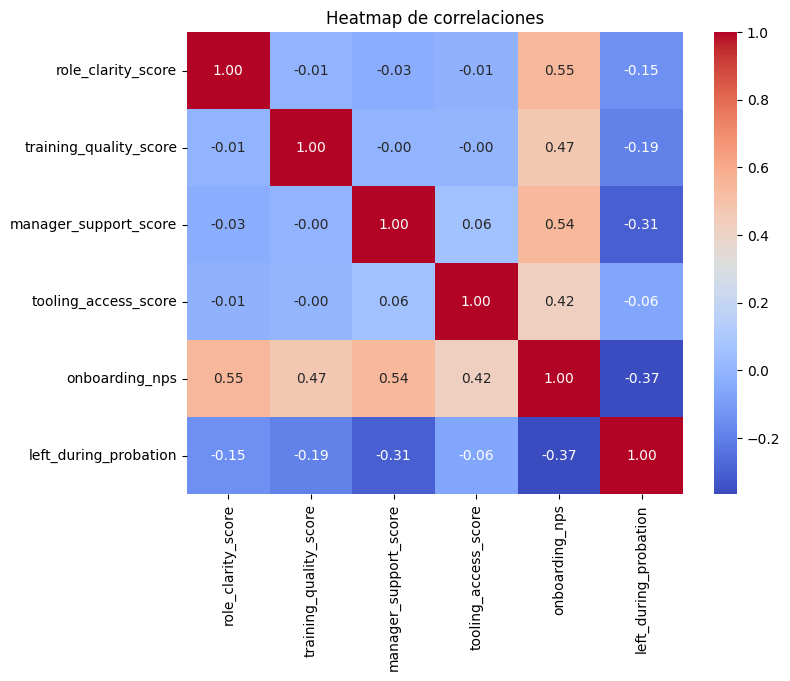

In [ ]:
# Seleccionamos variables numéricas relevantes y vemos su correlación con
# un Heat Map
cols_corr = [
    "role_clarity_score",
    "training_quality_score",
    "manager_support_score",
    "tooling_access_score",
    "onboarding_nps",
    "left_during_probation"
]

corr_matrix = employees[cols_corr].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap de correlaciones")
plt.show()

Se ve claramente que:

1) La puntuación del manager y la claridad del rol influye mucho en el NPS del onboarding.

2) La probabilidad de salida se relaciona más con la puntuación del manager, la calidad de la formación y la claridad del rol.

**PREDICCIÓN USANDO UN MODELO DE MACHINE LEARNING**

Como hemos de predecir la probabilidad de salida en el periodo de prueba (left_during_probation), usaremos las features que conforman el cálculo de onboarding_nps (esa no, porque está relacionada con ellas).

Usaremos una **regresión logística.**

In [ ]:
#Definimos X e Y

y = employees["left_during_probation"]

features = [
    "role_clarity_score",
    "training_quality_score",
    "manager_support_score",
    "tooling_access_score"
]

x = employees[features]

In [ ]:
#Definimos los datos de test y los datos de train

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.25,
    random_state=42,
    stratify=y  # importante para mantener proporción de left=1
)

In [ ]:
#Definimos el modelo de Regresión Logísitica y lo entrenamos

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# Creamos las predicciones

y_pred = model.predict(x_test)
y_proba = model.predict_proba(x_test)[:, 1]

Dado cómo construimos el dataset:

1) manager_support debería tener mayor peso

2) role_clarity segundo

3) training_quality tercero

4) tooling_access el menor

- ROC-AUC esperado:

~0.70–0.80

Si sale ~0.75 → modelo sólido.

In [ ]:
#Evaluamos el modelo

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

ROC-AUC: 0.815

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.99      0.89        78
           1       0.80      0.18      0.30        22

    accuracy                           0.81       100
   macro avg       0.81      0.58      0.59       100
weighted avg       0.81      0.81      0.76       100


Confusion Matrix:

[[77  1]
 [18  4]]


Recall es bajo, se detecta bien a los que se quedan, pero mal a los que se van.

Vamos a ajustarlo, cambiamos el umbral de 0.5 a 0.3

In [ ]:
# Ajustamos umbral
threshold = 0.30
y_pred_adjusted = (y_proba >= threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print("Nuevo Classification Report:\n")
print(classification_report(y_test, y_pred_adjusted))

print("Nueva Matriz de Confusión:\n")
print(confusion_matrix(y_test, y_pred_adjusted))

Nuevo Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.78      0.83        78
           1       0.45      0.64      0.53        22

    accuracy                           0.75       100
   macro avg       0.67      0.71      0.68       100
weighted avg       0.79      0.75      0.76       100

Nueva Matriz de Confusión:

[[61 17]
 [ 8 14]]


Aqui está mejor, anque el accuracy baja y el recall de 0 también, mejoramos en 1.

Es mejor porque:

En People Analytics sí.

1) Intervenir sobre alguien que luego no se va
→ coste bajo.

2) No detectar a alguien que se va
→ coste alto.

Por eso preferimos mayor recall.

**VISUALES FINALES**

*Coeficientes del modelo*

In [ ]:
#Coeficientes del modelo

import plotly.express as px

coef = pd.Series(model.coef_[0], index=features).sort_values()
df_coef = coef.reset_index()
df_coef.columns = ["feature", "coef"]

fig = px.bar(
    df_coef,
    x="coef",
    y="feature",
    orientation="h",
    title="Impacto de cada variable (coeficientes - Regresión Logística)",
    hover_data={"coef":":.3f"}
)
fig.add_vline(x=0, line_dash="dash")
fig.show()

Barras hacia la izquierda (negativas) = bajan el riesgo de salida

Cuanto más larga la barra = más influencia

*Curva ROC (interactiva) + AUC*

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import plotly.graph_objects as go

fpr, tpr, thr = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode="lines", name=f"ROC (AUC={auc:.3f})"))
fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode="lines", name="Azar", line=dict(dash="dash")))
fig.update_layout(
    title="Curva ROC (Regresión Logística)",
    xaxis_title="False Positive Rate (Falsos positivos)",
    yaxis_title="True Positive Rate (Recall)",
    width=750,
    height=500
)
fig.show()

Cuanto más se aleja la curva de la diagonal “azar”, mejor.

El AUC es la “nota” de discriminación.

*Recall vs Threshold*

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score
import plotly.graph_objects as go

# Umbral que quieres usar como "decisión"
chosen_threshold = 0.30

thresholds = np.linspace(0.05, 0.95, 19)

rows = []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    rows.append({
        "Umbral": float(t),
        "Precisión (salida=1)": precision_score(y_test, y_pred_t, zero_division=0),
        "Recall (salida=1)": recall_score(y_test, y_pred_t, zero_division=0)
    })

df_thr = pd.DataFrame(rows)

# Calculamos las métricas en el umbral elegido
y_pred_chosen = (y_proba >= chosen_threshold).astype(int)
prec_chosen = precision_score(y_test, y_pred_chosen, zero_division=0)
rec_chosen = recall_score(y_test, y_pred_chosen, zero_division=0)

fig = go.Figure()

# Líneas
fig.add_trace(go.Scatter(
    x=df_thr["Umbral"], y=df_thr["Precisión (salida=1)"],
    mode="lines+markers", name="Precisión (salida=1)"
))
fig.add_trace(go.Scatter(
    x=df_thr["Umbral"], y=df_thr["Recall (salida=1)"],
    mode="lines+markers", name="Recall (salida=1)"
))

# Línea vertical del umbral elegido
fig.add_vline(x=chosen_threshold, line_dash="dash")

# Puntos destacados en el umbral elegido
fig.add_trace(go.Scatter(
    x=[chosen_threshold], y=[prec_chosen],
    mode="markers+text", name="Precisión en umbral elegido",
    text=[f"{prec_chosen:.2f}"], textposition="top center"
))
fig.add_trace(go.Scatter(
    x=[chosen_threshold], y=[rec_chosen],
    mode="markers+text", name="Recall en umbral elegido",
    text=[f"{rec_chosen:.2f}"], textposition="bottom center"
))

fig.update_layout(
    title="Trade-off del umbral: Precisión vs Recall (clase salida=1)",
    xaxis_title="Umbral de decisión (probabilidad para marcar riesgo)",
    yaxis_title="Valor de la métrica (0–1)",
    legend_title="Métricas",
    width=850,
    height=520
)

fig.show()

# ¿Qué nos dice este gráfico?

Este gráfico muestra algo muy sencillo:

Cuando usamos el modelo para detectar personas con riesgo de irse,
tenemos que decidir qué nivel de probabilidad consideramos “alto riesgo”.

Si ponemos el nivel muy bajo:
- Detectamos casi todas las personas que se van.
- Pero también señalamos como riesgo a muchas que en realidad no se irán.

Si ponemos el nivel muy alto:
- Solo marcamos como riesgo a casos muy claros.
- Pero dejamos escapar a muchas personas que sí se irán.

En el punto elegido (0.30):

- Detectamos el 64% de las personas que realmente se van.
- Pero no todas las personas marcadas como riesgo acabarán yéndose.

En resumen:

El gráfico demuestra que el modelo no es perfecto,
pero nos permite elegir cuán estrictos o preventivos queremos ser.

Podemos decidir si preferimos:
detectar más riesgo (aunque nos equivoquemos más),
o ser más conservadores y detectar menos casos.

# Conclusión final del modelo

El modelo de regresión logística permite estimar el riesgo de salida
durante el periodo de prueba utilizando únicamente las variables del onboarding.

Los resultados muestran que:

- El apoyo del manager y la claridad del rol son los principales factores asociados a la salida temprana.
- El modelo tiene capacidad predictiva suficiente
  para ser utilizado como herramienta de priorización de riesgo.

*Este análisis demuestra cómo People Analytics puede apoyar decisiones preventivas en procesos de onboarding.*